In [2]:
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.2 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import re
import math
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Semantic retrieval
from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder
import faiss

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print("All imports are successful.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

All imports are successful.
NumPy: 2.0.2
Pandas: 2.3.3


In [4]:
# ── Configuration ──────────────────────────────────────────────────────────────
BASE_DIR   = Path('/kaggle/input/competitions/llm-agentic-legal-information-retrieval')
OUTPUT_DIR = Path('/kaggle/working')

# Column names — confirmed from competition schema
Q_FIELD     = 'query'           # question text
LABEL_FIELD = 'gold_citations'  # semicolon-separated gold citations
ID_FIELD    = 'query_id'        # unique query identifier

# Retrieval settings
TFIDF_TOP_K = 20
LSA_TOP_K   = 20
FINAL_TOP_K = 10

# LSA settings
LSA_COMPONENTS = 256
MAX_FEATURES   = 100_000
MAX_CHARS      = 512

SEED = 42
np.random.seed(SEED)

print("Config is ready")

Config is ready


In [5]:
train_df = pd.read_csv(BASE_DIR / 'train.csv')
val_df   = pd.read_csv(BASE_DIR / 'val.csv')
test_df  = pd.read_csv(BASE_DIR / 'test.csv')
laws_df  = pd.read_csv(BASE_DIR / 'laws_de.csv')
court_df = pd.read_csv(BASE_DIR / 'court_considerations.csv')

print(f'train shape               : {train_df.shape}')
print(f'val shape                 : {val_df.shape}')
print(f'test shape                : {test_df.shape}')
print(f'laws_de shape             : {laws_df.shape}')
print(f'court_considerations shape: {court_df.shape}')

train shape               : (1139, 3)
val shape                 : (10, 3)
test shape                : (40, 2)
laws_de shape             : (175933, 3)
court_considerations shape: (2476315, 2)


In [6]:
train_df.head(3)

,query_id,query,gold_citations
0,train_0001,Die A AG betreibt seit den 1970er-Jahren auf d...,Art. 10a Abs. 1 USG;Art. 2 Abs. 1 UVPV;Art. 10...
1,train_0002,Die Alpha Consulting AG kann nun ihr Grundstüc...,Art. 975 ZGB;Art. 974 Abs. 2 ZGB;Art. 973 ZGB;...
2,train_0003,Das Kompetenzzentrum Völkerstrafrecht bei der ...,Art. 264m StGB


In [7]:
laws_df.head(3)

,citation,text,title
0,Art. 1 112,Die Einwohnergemeinde Bern tritt der Schweizer...,Übereinkunft vom 22. Juni 1875 zwischen dem Sc...
1,Art. 2 112,Die Einwohnergemeinde Bern wird ferner der Sch...,Übereinkunft vom 22. Juni 1875 zwischen dem Sc...
2,Art. 3 Abs. 1 112,1 Falls die Schweizerische Eidgenossenschaft z...,Übereinkunft vom 22. Juni 1875 zwischen dem Sc...


In [8]:
court_df.head(3)

,citation,text
0,BGE 139 I 2 E. 1.12.2011,betr. Verweigerung der Beiladung seien gutzuhe...
1,BGE 139 I 2 E. 2,Eventualiter sei die Rückweisung an die Vorins...
2,BGE 139 I 2 E. 5.1,"In der Sache ist vorweg zu prüfen, ob der Ents..."


In [9]:
def parse_gold_citations(raw) -> List[str]:
    """Parse semicolon-separated gold citation string into a list."""
    if isinstance(raw, list):
        return [str(g).strip() for g in raw]
    return [g.strip() for g in str(raw).split(';') if g.strip()]


# Basic stats
print(f'Null queries        : {train_df[Q_FIELD].isna().sum()}')
print(f'Null gold_citations : {train_df[LABEL_FIELD].isna().sum()}')

# Citations per question
n_cites = train_df[LABEL_FIELD].apply(lambda x: len(parse_gold_citations(x)))
print(f'\nCitations per question:')
print(n_cites.describe().round(2))

Null queries        : 0
Null gold_citations : 0

Citations per question:
count    1139.00
mean        4.09
std         4.51
min         1.00
25%         1.00
50%         2.00
75%         5.00
max        44.00
Name: gold_citations, dtype: float64


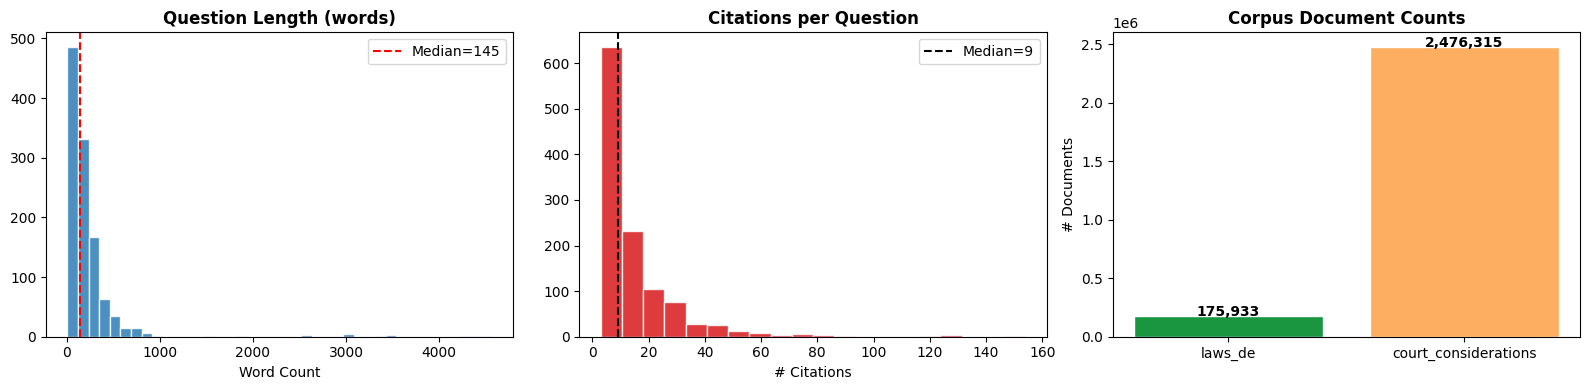

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Question length distribution
q_lens = train_df[Q_FIELD].str.split().str.len()
axes[0].hist(q_lens, bins=40, color='#2c7bb6', edgecolor='white', alpha=0.85)
axes[0].axvline(q_lens.median(), color='red', linestyle='--',
                label=f'Median={q_lens.median():.0f}')
axes[0].set_title('Question Length (words)', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].legend()

# Citations per question
# Assumes citations are stored as a space/comma separated string — adjust if needed
n_cites = train_df[LABEL_FIELD].astype(str).str.split().str.len()
axes[1].hist(n_cites, bins=20, color='#d7191c', edgecolor='white', alpha=0.85)
axes[1].axvline(n_cites.median(), color='black', linestyle='--',
                label=f'Median={n_cites.median():.0f}')
axes[1].set_title('Citations per Question', fontweight='bold')
axes[1].set_xlabel('# Citations')
axes[1].legend()

# Corpus source breakdown
laws_df_tagged  = laws_df.copy();  laws_df_tagged['source']  = 'laws_de'
court_df_tagged = court_df.copy(); court_df_tagged['source'] = 'court_considerations'
source_counts = pd.Series({'laws_de': len(laws_df), 'court_considerations': len(court_df)})
axes[2].bar(source_counts.index, source_counts.values,
            color=['#1a9641', '#fdae61'], edgecolor='white')
axes[2].set_title('Corpus Document Counts', fontweight='bold')
axes[2].set_ylabel('# Documents')
for i, v in enumerate(source_counts.values):
    axes[2].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
class LegalCorpus:
    """
    Combines laws_de and court_considerations into a single
    searchable corpus. Both files use 'citation' as ID and 'text' as content.
    Works directly with DataFrames — no dict conversion needed.
    """

    def __init__(
        self,
        laws_df: pd.DataFrame,
        court_df: pd.DataFrame,
        id_col: str            = 'citation',
        text_col: str          = 'text',
        title_col: Optional[str] = None       # no title column in either file
    ):
        laws  = laws_df.copy();  laws['source']  = 'law'
        court = court_df.copy(); court['source'] = 'court'

        self.df       = pd.concat([laws, court], ignore_index=True)
        self.id_col   = id_col
        self.text_col = text_col
        self.title_col = title_col

        # Fast citation → row index lookup
        self.id2idx = pd.Series(
            self.df.index, index=self.df[id_col].astype(str)
        ).to_dict()

        # Pre-built text list for indexing
        if title_col and title_col in self.df.columns:
            self.texts = (
                self.df[title_col].fillna('') + ' ' + self.df[text_col].fillna('')
            ).tolist()
        else:
            self.texts = self.df[text_col].fillna('').tolist()

        self.ids = self.df[id_col].astype(str).tolist()

        print(f'Corpus size : {len(self.df):,} documents')
        print(f'  laws_de             : {len(laws):,}')
        print(f'  court_considerations: {len(court):,}')

    def get_text(self, citation: str) -> str:
        idx = self.id2idx.get(str(citation))
        return self.texts[idx] if idx is not None else ''

    def get_row(self, citation: str) -> pd.Series:
        idx = self.id2idx.get(str(citation))
        return self.df.iloc[idx] if idx is not None else pd.Series()


corpus = LegalCorpus(
    laws_df   = laws_df,
    court_df  = court_df,
    id_col    = 'citation',
    text_col  = 'text',
    title_col = None
)

Corpus size : 2,652,248 documents
  laws_de             : 175,933
  court_considerations: 2,476,315


In [13]:
# ── Sanity check: verify gold citations exist in corpus ───────────────────────
sample_gold = parse_gold_citations(train_df[LABEL_FIELD].iloc[0])
print(f'Query        : {train_df[Q_FIELD].iloc[0]}')
print(f'Gold citations: {sample_gold}')
print(f'\nFound in corpus:')
for g in sample_gold[:5]:
    found = g in corpus.id2idx
    print(f"  '{g}' → {'✅ found' if found else '❌ NOT found'}")

Query        : Die A AG betreibt seit den 1970er-Jahren auf der Parzelle Nr. yyy (Wohn- und Gewerbezone) ein Recyclingunternehmen. Das Unternehmen verarbeitet vorwiegend Metallschrott. Dieser wird im Aussenbereich des Betriebsgeländes zwischengelagert und dort von einem fest instal lierten Metallschredder für die Weiterverarbeitung zerkleinert. Im Jahr 2018 wurde der 1983 bewilligte Metallschredder umfassend modernisiert; nur wenige Teile der Gehäusekonstruktion wurden weiterverwendet. Aufgrund der Modernisierung stieg die jährliche Verarbeitungskapazität von 75'000 auf 84'000 Tonnen, und die durchschnittliche Betriebsleistung pro Tag dehnte sich von zehn auf zwölf Stunden aus. Im Herbst 2020 kauft B das Wohnhaus auf der Parzelle Nr. zzz (Wohn- und Gewerbezone), welches an das Grundstück Nr. yyy angrenzt. Nach kurzer Zeit fühlt er sich vom Lärm des Me tallschredders gestört, zumal dieser gelegentlich bis in die späten Abendstunden (23.00 Uhr) in Betrieb ist. Er beschwert sich deshalb b

In [14]:
# ── Check overall corpus coverage ────────────────────────────────────────────
all_gold = train_df[LABEL_FIELD].dropna().apply(parse_gold_citations).explode()

total       = len(all_gold)
found       = all_gold.apply(lambda c: c in corpus.id2idx).sum()
missing     = total - found

print(f'Total gold citations : {total:,}')
print(f'Found in corpus      : {found:,} ({found/total*100:.1f}%)')
print(f'Missing from corpus  : {missing:,} ({missing/total*100:.1f}%)')

# Which laws are most commonly missing?
missing_citations = all_gold[~all_gold.apply(lambda c: c in corpus.id2idx)]
missing_laws = missing_citations.str.split().str[-1].value_counts()
print(f'\nTop missing law abbreviations:')
print(missing_laws.head(10))

Total gold citations : 4,659
Found in corpus      : 3,319 (71.2%)
Missing from corpus  : 1,340 (28.8%)

Top missing law abbreviations:
gold_citations
ZGB     218
OR      184
StGB    129
BV       75
DSG      54
LugÜ     43
URG      41
ZPO      40
IPRG     39
JStG     36
Name: count, dtype: int64


In [15]:
# ── Check val_df coverage too ─────────────────────────────────────────────────
val_gold    = val_df[LABEL_FIELD].dropna().apply(parse_gold_citations).explode()
val_found   = val_gold.apply(lambda c: c in corpus.id2idx).sum()
val_missing = len(val_gold) - val_found

print(f'\nVal set coverage:')
print(f'  Total   : {len(val_gold)}')
print(f'  Found   : {val_found} ({val_found/len(val_gold)*100:.1f}%)')
print(f'  Missing : {val_missing} ({val_missing/len(val_gold)*100:.1f}%)')


Val set coverage:
  Total   : 251
  Found   : 251 (100.0%)
  Missing : 0 (0.0%)


In [16]:
# ── Val set citation source breakdown ────────────────────────────────────────
# Confirms both sources are needed for good recall
val_gold_all = val_df[LABEL_FIELD].dropna().apply(parse_gold_citations).explode()

in_laws  = val_gold_all.apply(lambda c: c in set(laws_df['citation'].astype(str))).sum()
in_court = val_gold_all.apply(lambda c: c in set(court_df['citation'].astype(str))).sum()
neither  = len(val_gold_all) - in_laws - in_court

print(f'Val gold citations breakdown:')
print(f'  In laws_de              : {in_laws}  ({in_laws/len(val_gold_all)*100:.1f}%)')
print(f'  In court_considerations : {in_court} ({in_court/len(val_gold_all)*100:.1f}%)')
print(f'  In neither (ceiling gap): {neither}  ({neither/len(val_gold_all)*100:.1f}%)')
print(f'\n Max achievable recall ≈ {(in_laws+in_court)/len(val_gold_all)*100:.1f}%')

Val gold citations breakdown:
  In laws_de              : 149  (59.4%)
  In court_considerations : 102 (40.6%)
  In neither (ceiling gap): 0  (0.0%)

 Max achievable recall ≈ 100.0%


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import scipy.sparse as sp

In [18]:
class TFIDFRetriever:
    """
    TF-IDF retrieval using sparse matrices.
    
    """

    def __init__(
        self,
        corpus: LegalCorpus,
        source_filter: Optional[str] = None,
        max_chars: int   = MAX_CHARS,
        max_features: int = MAX_FEATURES
    ):
        print('Building TF-IDF index …')
        self.corpus = corpus

        if source_filter is not None:
            mask     = corpus.df['source'] == source_filter
            self.ids = corpus.df.loc[mask, corpus.id_col].astype(str).tolist()
            texts    = corpus.df.loc[mask, corpus.text_col].fillna('').str[:max_chars].tolist()
        else:
            self.ids = corpus.ids
            texts    = [t[:max_chars] for t in corpus.texts]

        print(f'  Indexing {len(texts):,} documents …')
        self.vectorizer = TfidfVectorizer(
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            max_features=max_features,
            strip_accents='unicode',
            analyzer='word',
            ngram_range=(1, 2),
            token_pattern=r'(?u)(?:§+\d+|\b\w+(?:-\w+)*\b)'
        )
        self.index = self.vectorizer.fit_transform(texts)
        print(f'TF-IDF index: {self.index.shape}, nnz={self.index.nnz:,}')

    def retrieve(self, query: str, top_k: int = TFIDF_TOP_K) -> List[Tuple[str, float]]:
        q_vec   = self.vectorizer.transform([query])
        scores  = linear_kernel(q_vec, self.index).flatten()
        top_idx = np.argsort(scores)[::-1][:top_k]
        return [(self.ids[i], float(scores[i])) for i in top_idx]


# source_filter=None → indexes both laws_de and court_considerations
tfidf_retriever = TFIDFRetriever(corpus, source_filter=None)

Building TF-IDF index …
  Indexing 2,652,248 documents …
TF-IDF index: (2652248, 100000), nnz=200,524,368


In [28]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

In [31]:
from sentence_transformers import SentenceTransformer

class MultilingualRetriever:
    """
    Dense retrieval using a multilingual sentence transformer.
    Maps English queries and German/FR/IT documents into the same vector space.
    """
    def __init__(self, corpus: LegalCorpus, max_chars: int = MAX_CHARS,
                 model_name: str = 'intfloat/multilingual-e5-small'):
        print(f'Building multilingual index with {model_name} …')
        self.corpus = corpus
        self.ids    = corpus.ids
        self.model = SentenceTransformer(model_name, device=device)

        texts = [f'passage: {t[:max_chars]}' for t in corpus.texts]  # e5 prefix
        print(f'  Encoding {len(texts):,} documents …')
        embeddings = self.model.encode(
            texts,
            batch_size=1024,          # larger batch fits on GPU
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype('float32')          # FAISS needs float32

        dim        = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dim)
        self.index.add(embeddings)
        print(f'Multilingual index: {self.index.ntotal:,} vectors (dim={dim})')

    def retrieve(self, query: str, top_k: int = LSA_TOP_K) -> List[Tuple[str, float]]:
        q_vec = self.model.encode(
            [f'query: {query}'], normalize_embeddings=True, convert_to_numpy=True
        ).astype('float32')
        scores, indices = self.index.search(q_vec, top_k)
        return [(self.ids[i], float(s)) for i, s in zip(indices[0], scores[0])]


multilingual_retriever = MultilingualRetriever(corpus)


Building multilingual index with intfloat/multilingual-e5-small …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoding 2,652,248 documents …


Batches:   0%|          | 0/2591 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [21]:
def reciprocal_rank_fusion(
    ranked_lists: List[List[Tuple[str, float]]],
    k: int     = 60,
    top_n: int = FINAL_TOP_K
) -> List[Tuple[str, float]]:
    """
    Merge multiple ranked lists via RRF.
    score = sum(1 / (rank + k)) across all lists.
    Retriever-agnostic — works with any (doc_id, score) lists.
    """
    rrf_scores: dict = defaultdict(float)
    for ranked in ranked_lists:
        for rank, (doc_id, _) in enumerate(ranked, start=1):
            rrf_scores[doc_id] += 1.0 / (rank + k)
    merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return merged[:top_n]


def hybrid_retrieve(
    query: str,
    tfidf: TFIDFRetriever,
    mltl: MultilingualRetriever = None,
    final_k: int = FINAL_TOP_K
) -> List[Tuple[str, float]]:
    """
    Retrieve from TF-IDF and optionally LSA, fuse with RRF.
    """
    ranked_lists = [tfidf.retrieve(query)]
    if mltl is not None:
        ranked_lists.append(mltl.retrieve(query))
    return reciprocal_rank_fusion(ranked_lists, top_n=final_k)


# Sanity check
sample_q = val_df[Q_FIELD].iloc[0]
results  = hybrid_retrieve(sample_q, tfidf_retriever, mltl=multilingual_retriever)
print(f'Query : {sample_q}')
print(f'Top-5 results:')
for citation, score in results[:5]:
    snippet = corpus.get_text(citation)[:100].replace('\n', ' ')
    print(f'  [{citation}] RRF={score:.4f} | {snippet}…')

Query : May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit. b StPO (risk of collusion) consistent with the principle of proportionality when the accused—detained after an alleged late‑night assault and theft of a courier satchel containing, inter alia, €5,600—was remanded by an order dated 18 October 2024 for a maximum period up to 15 January 2025, the prosecutor sought an extension on 10 December 2024 primarily citing a concrete risk that the detainee would influence witnesses or tamper with evidence and a risk of reoffending, while the detainee opposed the extension on the ground that most witnesses have already been interviewed, the investigative steps still pending are essentially technical (phone data extraction, CCTV image analysis, and bank record checks), his release would therefore not jeopardize the inquiry, and the alleged victim has withdrawn the complaint—i.e. does the asserted concrete risk of collusion and considerations o

In [22]:
# Load once — reuse across all calls
reranker_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')


def cross_encoder_rerank(
    question: str,
    candidates: List[Tuple[str, float]],
    corpus: LegalCorpus,
    max_chars: int = 300
) -> List[str]:
    """
    Rerank candidates using cross-encoder.
    Scores each (question, document) pair directly —
    stronger signal than RRF alone. Runs locally, no API needed.
    """
    pairs  = [
        (question, corpus.get_text(citation)[:max_chars])
        for citation, _ in candidates
    ]
    scores = reranker_model.predict(pairs)
    ranked = sorted(
        zip([citation for citation, _ in candidates], scores),
        key=lambda x: x[1], reverse=True
    )
    return [citation for citation, _ in ranked]


print('Cross-encoder reranker is ready.')

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-encoder reranker is ready.


In [23]:
def citation_f1(predicted: List[str], gold: List[str]) -> Tuple[float, float, float]:
    """Compute citation-level Precision, Recall, F1."""
    pred_set  = set(predicted)
    gold_set  = set(gold)
    tp        = len(pred_set & gold_set)
    precision = tp / len(pred_set) if pred_set else 0.0
    recall    = tp / len(gold_set) if gold_set else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def evaluate_pipeline(
    df: pd.DataFrame,
    corpus: LegalCorpus,
    tfidf: TFIDFRetriever,
    mltl: MultilingualRetriever = None,
    use_reranker: bool = False
) -> pd.DataFrame:
    """
    Run pipeline on a labelled DataFrame.
    Pipeline: TF-IDF → (+ LSA) → RRF → (cross-encoder reranker)
    """
    rows = []

    for _, row in df.iterrows():
        question = row[Q_FIELD]
        gold     = parse_gold_citations(row[LABEL_FIELD])

        # Step 1: Hybrid retrieval
        candidates = hybrid_retrieve(question, tfidf, lsa=lsa)

        # Step 2: Optional cross-encoder reranking
        if use_reranker:
            predicted = cross_encoder_rerank(question, candidates, corpus)
        else:
            predicted = [citation for citation, _ in candidates]

        p, r, f1 = citation_f1(predicted, gold)
        rows.append({
            'query_id' : row[ID_FIELD],
            'question' : str(question)[:80],
            'precision': p,
            'recall'   : r,
            'f1'       : f1,
            'n_gold'   : len(gold),
            'n_pred'   : len(predicted)
        })

    results_df = pd.DataFrame(rows)

    print(f"\n{'='*50}")
    print(f" Evaluation on {len(results_df)} samples")
    print(f"{'='*50}")
    print(f" Mean Precision : {results_df['precision'].mean():.4f}")
    print(f" Mean Recall    : {results_df['recall'].mean():.4f}")
    print(f" Mean F1        : {results_df['f1'].mean():.4f}")
    print(f" Median F1      : {results_df['f1'].median():.4f}")
    print(f" F1 > 0.5       : {(results_df['f1'] > 0.5).sum()} / {len(results_df)}")
    print(f"{'='*50}")
    return results_df


# ── Evaluate all three configurations on val_df ───────────────────────────────
print('── 1. TF-IDF only ──')
eval_tfidf = evaluate_pipeline(
    val_df, corpus, tfidf_retriever,
    use_reranker=False
)

print('\n── 2. TF-IDF + MLTL ──')
eval_hybrid = evaluate_pipeline(
    val_df, corpus, tfidf_retriever, mltl=multilingual_retriever,
    use_reranker=False
)

print('\n── 3. TF-IDF + MLTL + reranker_model ──')
eval_reranked = evaluate_pipeline(
    val_df, corpus, tfidf_retriever, mltl=multilingual_retriever,
    use_reranker=True
)

── 1. TF-IDF only ──

 Evaluation on 10 samples
 Mean Precision : 0.0000
 Mean Recall    : 0.0000
 Mean F1        : 0.0000
 Median F1      : 0.0000
 F1 > 0.5       : 0 / 10

── 2. TF-IDF + LSA hybrid ──

 Evaluation on 10 samples
 Mean Precision : 0.0000
 Mean Recall    : 0.0000
 Mean F1        : 0.0000
 Median F1      : 0.0000
 F1 > 0.5       : 0 / 10

── 3. TF-IDF + LSA + reranker_model ──

 Evaluation on 10 samples
 Mean Precision : 0.0000
 Mean Recall    : 0.0000
 Mean F1        : 0.0000
 Median F1      : 0.0000
 F1 > 0.5       : 0 / 10


In [24]:
print(val_df.columns.tolist())
print(val_df.head(2))

['query_id', 'query', 'gold_citations']
  query_id                                              query  \
0  val_001  May a court lawfully order a three‑month exten...   
1  val_002  A claimant holding a national vocational diplo...   

                                      gold_citations  
0  Art. 221 Abs. 1 StPO;Art. 140 Abs. 1 StGB;Art....  
1  Art. 8 Abs. 1 ATSG;Art. 8 Abs. 1 IVG;Art. 17 A...  


In [25]:
results = hybrid_retrieve(val_df[Q_FIELD].iloc[0], tfidf_retriever, lsa=lsa_retriever)
print(results[:5])

[('4A_355/2021 E. 3', 0.030798389007344232), ('4A_505/2017 E. 4', 0.01639344262295082), ('7B_859/2024 E. 5.2', 0.01639344262295082), ('4A_574/2023 24.05.2024 E. 3.2', 0.016129032258064516), ('2C_732/2008 24.03.2009 E. 2.2', 0.016129032258064516)]


In [26]:
query = val_df[Q_FIELD].iloc[0]
gold  = parse_gold_citations(val_df[LABEL_FIELD].iloc[0])
pred  = [c for c, _ in hybrid_retrieve(query, tfidf_retriever, lsa=lsa_retriever)]

print("Gold :", gold)
print("Pred :", pred)
print("\nExact matches:", set(pred) & set(gold))


Gold : ['Art. 221 Abs. 1 StPO', 'Art. 140 Abs. 1 StGB', 'Art. 396 Abs. 1 StPO', 'Art. 222 StPO', 'Art. 393 Abs. 1 StPO', 'Art. 382 Abs. 1 StPO', 'Art. 385 Abs. 1 StPO', 'Art. 221 Abs. 2 StPO', 'Art. 227 Abs. 1 StPO', 'Art. 212 Abs. 3 StPO', 'Art. 390 Abs. 2 StPO', 'Art. 422 Abs. 1 StPO', 'Art. 422 Abs. 2 StPO', 'Art. 428 Abs. 1 StPO', 'Art. 135 Abs. 4 StPO', 'Art. 100 Abs. 1 BGG', 'Art. 135 Abs. 3 StPO', 'Art. 37 Abs. 1 StBOG', 'Art. 39 Abs. 1 StBOG', 'BGE 137 IV 122 E. 6.2', 'BGE 137 IV 122 E. 6.4', 'BGE 137 IV 122 E. 4.2', 'BGE 132 I 21 E. 3.2', '1B_210/2023 E. 4.1', 'BGE 132 I 21 E. 3.2.2', '1B_536/2018 E. 5.1', 'BGE 139 IV 270 E. 3.1', 'BGE 133 I 168 E. 4.1', 'BGE 143 IV 168 E. 5.1', 'BGE 133 I 270 E. 3.4.2', 'BGE 137 IV 122 E. 4.1', 'BGE 132 I 21 E. 3.2.1', '1B_90/2021 E. 2.1', '1B_90/2021 E. 2.4', '7B_496/2025 E. 3.2', '7B_231/2025 E. 4.1', '7B_69/2024 E. 3.3.2', '7B_301/2024 E. 2.4', '7B_12/2025 E. 2.2', '1B_357/2022 E. 3.1', '1B_15/2023 E. 3.1', '1B_28/2022 E. 4.1']
Pred : ['4A

In [ ]:
# ── Compare all three configurations ─────────────────────────────────────────
summary = pd.DataFrame({
    'TF-IDF'                  : eval_tfidf[['precision','recall','f1']].mean(),
    'TF-IDF + LSA'            : eval_hybrid[['precision','recall','f1']].mean(),
    'TF-IDF + LSA + reranker' : eval_reranked[['precision','recall','f1']].mean(),
}).T.round(4)

print(summary)

summary.plot(kind='bar', figsize=(10, 4), colormap='Set2', edgecolor='white', rot=0)
plt.title('Retrieval Pipeline Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pipeline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()